In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./retail_sales_large.csv")

In [3]:
df.head(10)

,InvoiceID,CustomerAge,Gender,ProductCategory,Quantity,UnitPrice,DiscountApplied,StoreType,CustomerRating,TotalAmount
0,INV5000,41,Male,Furniture,7,27.71,Yes,Offline,4.0,243
1,INV5001,51,Male,Clothing,100,26.19,Yes,Online,1.0,315
2,INV5002,38,Female,Furniture,2,2.69,No,Online,3.0,51
3,INV5003,23,Female,Groceries,9,68.19,Yes,Offline,3.0,344
4,INV5004,43,Female,Clothing,5,66.38,Yes,Online,5.0,315
5,INV5005,54,Female,Electronics,5,41.80,Yes,Online,NaN,493
6,INV5006,43,Male,Groceries,1,42.26,Yes,Online,5.0,125
7,INV5007,60,Female,Electronics,3,25.36,Yes,Online,NaN,-32
8,INV5008,29,Male,Groceries,4,24.42,No,Offline,3.0,325
9,INV5009,62,Female,Furniture,3,29.10,No,Offline,3.0,90


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   InvoiceID        1200 non-null   object 
 1   CustomerAge      1200 non-null   int64  
 2   Gender           1200 non-null   object 
 3   ProductCategory  1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   DiscountApplied  1200 non-null   object 
 7   StoreType        1200 non-null   object 
 8   CustomerRating   984 non-null    float64
 9   TotalAmount      1200 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 93.9+ KB


In [5]:
df.columns

Index(['InvoiceID', 'CustomerAge', 'Gender', 'ProductCategory', 'Quantity',
       'UnitPrice', 'DiscountApplied', 'StoreType', 'CustomerRating',
       'TotalAmount'],
      dtype='object')

In [6]:
df.describe(include="all")

,InvoiceID,CustomerAge,Gender,ProductCategory,Quantity,UnitPrice,DiscountApplied,StoreType,CustomerRating,TotalAmount
count,1200,1200.000000,1200,1200,1200.000000,1200.000000,1200,1200,984.000000,1200.000000
unique,1200,NaN,2,4,NaN,NaN,2,2,NaN,NaN
top,INV5000,NaN,Male,Clothing,NaN,NaN,No,Online,NaN,NaN
freq,1,NaN,607,316,NaN,NaN,609,603,NaN,NaN
mean,NaN,43.016667,NaN,NaN,17.215000,41.027492,NaN,NaN,3.012195,316.600000
std,NaN,15.196013,NaN,NaN,28.856213,19.589340,NaN,NaN,1.403329,239.229828
min,NaN,18.000000,NaN,NaN,1.000000,-19.540000,NaN,NaN,1.000000,-306.000000
25%,NaN,29.000000,NaN,NaN,3.000000,27.070000,NaN,NaN,2.000000,194.000000
50%,NaN,43.000000,NaN,NaN,6.000000,40.420000,NaN,NaN,3.000000,306.000000
75%,NaN,56.000000,NaN,NaN,9.000000,53.677500,NaN,NaN,4.000000,444.250000


## 1. Outlier detection for numerical columns

### a) Using Boxplot

In [7]:
numeric_col = ["CustomerAge", "Quantity", "UnitPrice", "CustomerRating", "TotalAmount"]

df_num = df[numeric_col].copy()

df_num.head(10)

,CustomerAge,Quantity,UnitPrice,CustomerRating,TotalAmount
0,41,7,27.71,4.0,243
1,51,100,26.19,1.0,315
2,38,2,2.69,3.0,51
3,23,9,68.19,3.0,344
4,43,5,66.38,5.0,315
5,54,5,41.80,NaN,493
6,43,1,42.26,5.0,125
7,60,3,25.36,NaN,-32
8,29,4,24.42,3.0,325
9,62,3,29.10,3.0,90


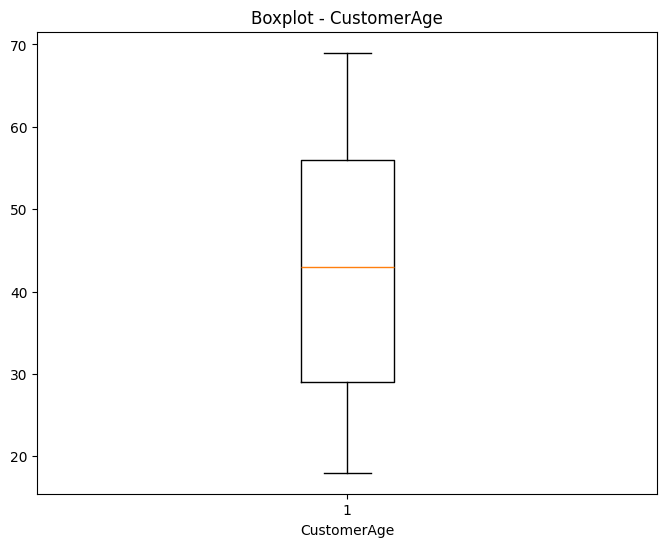

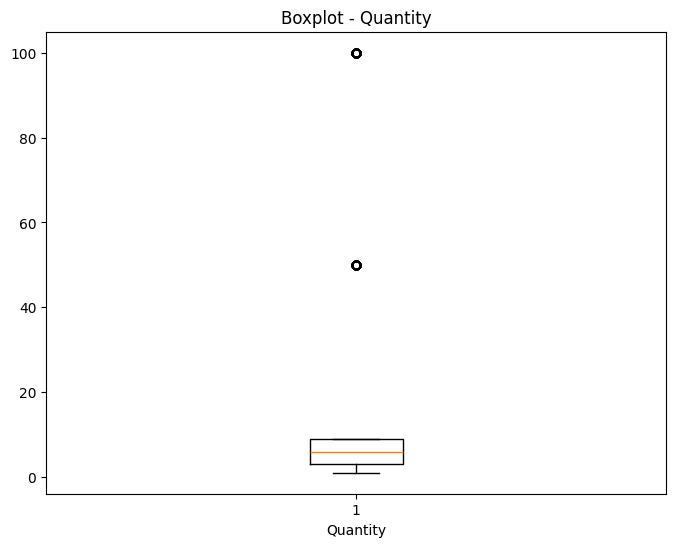

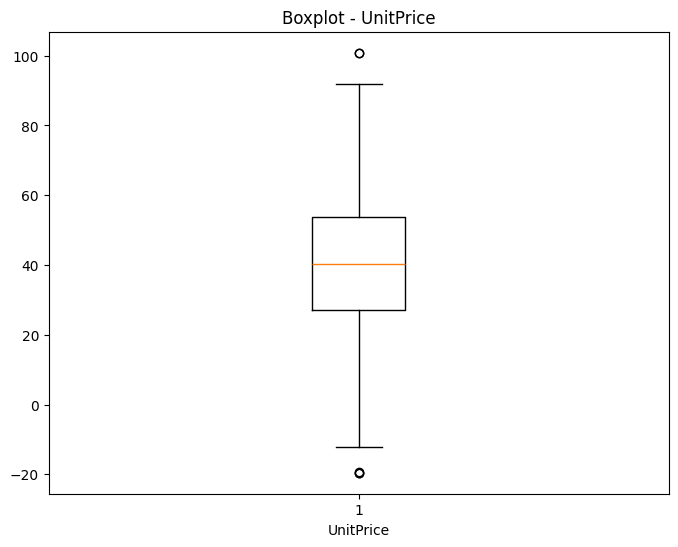

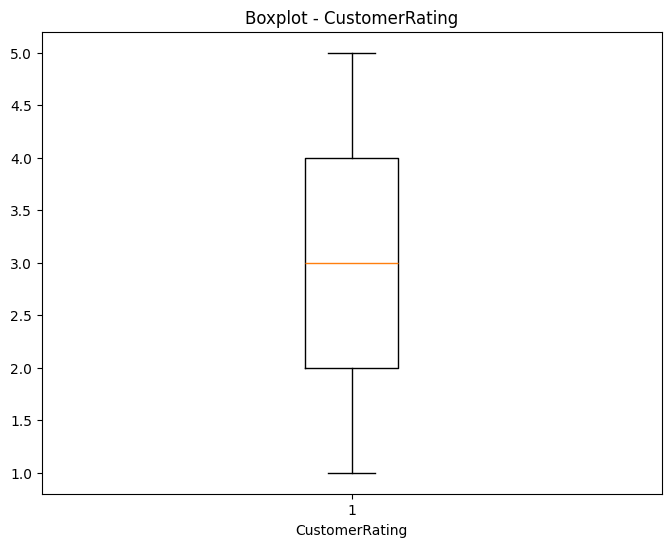

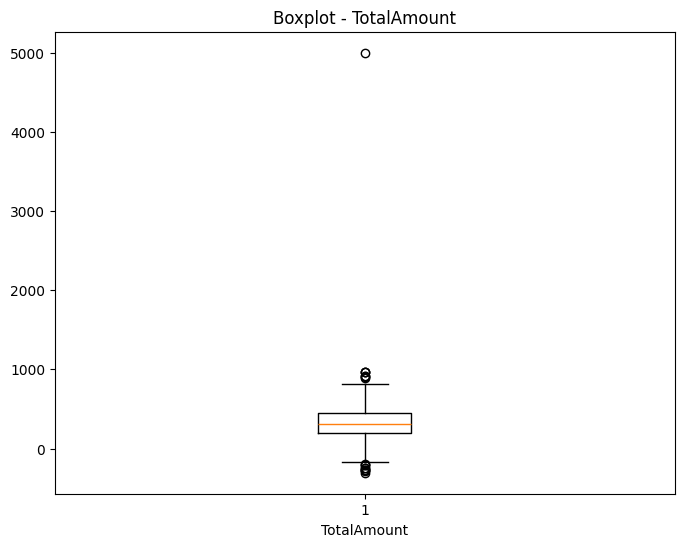

In [8]:
for col in numeric_col:
    plt.figure(figsize=(8,6))
    plt.boxplot(df_num[col].dropna())
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

Three columns have outliers namely: 
- Quantity 
- Unit price 
- Total amount

### b) Using Interquartile Range (IQR calculation)

In [9]:
for col in numeric_col:
    s = df_num[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_mask = (df_num[col] < lower) |  (df_num[col] > upper)
    
    print(f"=== {col} ===")
    print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"Lower={lower:.2f}, Upper={upper:.2f}")
    print(f"IQR Outliers: {outlier_mask.sum()}\n")

=== CustomerAge ===
Q1=29.00, Q3=56.00, IQR=27.00
Lower=-11.50, Upper=96.50
IQR Outliers: 0

=== Quantity ===
Q1=3.00, Q3=9.00, IQR=6.00
Lower=-6.00, Upper=18.00
IQR Outliers: 205

=== UnitPrice ===
Q1=27.07, Q3=53.68, IQR=26.61
Lower=-12.84, Upper=93.59
IQR Outliers: 5

=== CustomerRating ===
Q1=2.00, Q3=4.00, IQR=2.00
Lower=-1.00, Upper=7.00
IQR Outliers: 0

=== TotalAmount ===
Q1=194.00, Q3=444.25, IQR=250.25
Lower=-181.38, Upper=819.62
IQR Outliers: 18



Three columns have outliers namely: 
- Quantity: 205
- Unit price: 5
- Total amount: 18

### c) Z Score method

In [10]:
def zscore_series (s: pd.Series):
    s = s.dropna()
    return (s - s.mean() / s.std(ddof=0))

for col in numeric_col: 
    z = zscore_series(df_num[col])
    count = int((np.abs(z) > 3).sum())
    print(f'{col}: Z-score Outliers (> |3|) = {count}')

CustomerAge: Z-score Outliers (> |3|) = 1200
Quantity: Z-score Outliers (> |3|) = 887
UnitPrice: Z-score Outliers (> |3|) = 1180
CustomerRating: Z-score Outliers (> |3|) = 0
TotalAmount: Z-score Outliers (> |3|) = 1196


Four columns have outliers namely:
- Age
- Quantity 
- Unit price 
- Total amount

### d) Comparison of IQR and Z-score

In [11]:
# IQR
iqr_counts = {}
for col in numeric_col: 
    s = df_num[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    iqr_counts[col] = int(((df_num[col] < lower) | (df_num[col] > upper)).sum())
    
# Z-score
z_counts = {}
for col in numeric_col:
    z = zscore_series(df_num[col])
    z_counts[col] = int((np.abs(z) > 3).sum())
    
pd.DataFrame({ "IQR outliers": iqr_counts, "Z outliers": z_counts })

,IQR outliers,Z outliers
CustomerAge,0,1200
Quantity,205,887
UnitPrice,5,1180
CustomerRating,0,0
TotalAmount,18,1196


## 2. Handling outliers

### a) Trimming Method

In [12]:
# Calculate Q1, Q3 and IQR
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -12.841250000000002
Upper Limit: 93.58875


In [13]:
# Keep only rows within the limits
df_trimmed = df[(df['UnitPrice'] >= lower_limit) & (df['UnitPrice'] <= upper_limit)]

print("Original Shape: ", df.shape)
print("After Trimming: ", df_trimmed.shape)

Original Shape:  (1200, 10)
After Trimming:  (1195, 10)


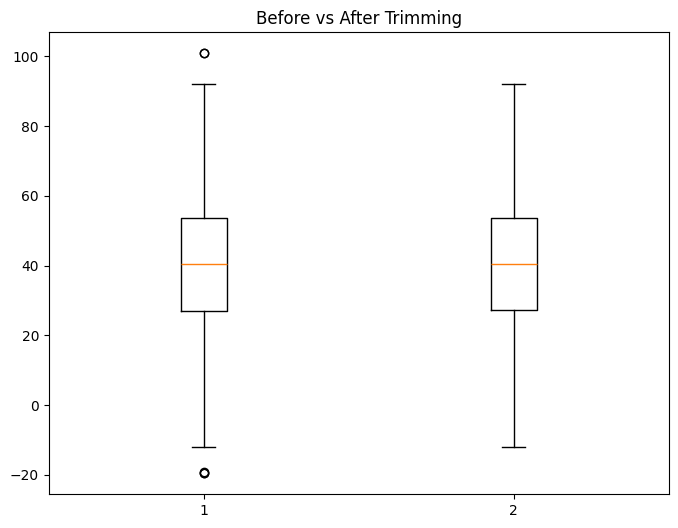

In [14]:
plt.figure(figsize=(8,6))
plt.boxplot([df["UnitPrice"].dropna(), df_trimmed["UnitPrice"].dropna()], label=["Before", "After"])
plt.title("Before vs After Trimming")
plt.show()

### b) Capping Method

In [15]:
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -12.841250000000002
Upper Limit: 93.58875


In [16]:
df_capped = df.copy()

df_capped["UnitPrice"] = np.where(
    df_capped["UnitPrice"] > upper_limit, upper_limit,
    np.where(df_capped["UnitPrice"] < lower_limit, lower_limit, df_capped["UnitPrice"])
)

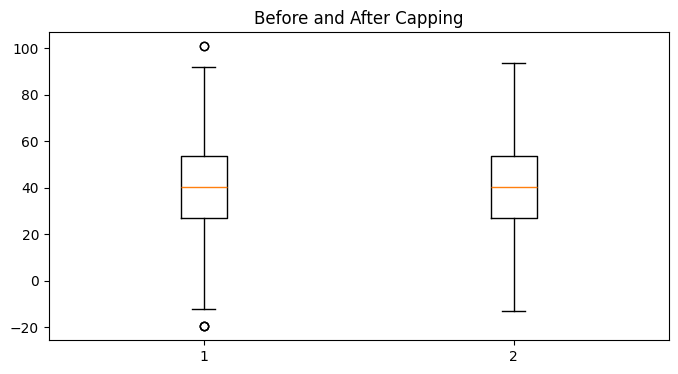

In [17]:
plt.figure(figsize=(8,4))
plt.boxplot([df["UnitPrice"].dropna(), df_capped["UnitPrice"]], label=["Before", "After"])
plt.title('Before and After Capping')
plt.show()

## 3. Encoding categorical columns into numerical columns

### a) Label Encoding

In [18]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [23]:
from sklearn.preprocessing import LabelEncoder

dfcopy = df.copy()
    
le = LabelEncoder()

dfcopy["Gender"] = le.fit_transform(dfcopy["Gender"])

dfcopy.head()

,InvoiceID,CustomerAge,Gender,ProductCategory,Quantity,UnitPrice,DiscountApplied,StoreType,CustomerRating,TotalAmount
0,INV5000,41,1,Furniture,7,27.71,Yes,Offline,4.0,243
1,INV5001,51,1,Clothing,100,26.19,Yes,Online,1.0,315
2,INV5002,38,0,Furniture,2,2.69,No,Online,3.0,51
3,INV5003,23,0,Groceries,9,68.19,Yes,Offline,3.0,344
4,INV5004,43,0,Clothing,5,66.38,Yes,Online,5.0,315


In [24]:
dfcopy["Gender"].value_counts()

Gender
1    607
0    593
Name: count, dtype: int64

### b) One Hot Encoding

In [26]:
dfcopy["ProductCategory"].unique()

array(['Furniture', 'Clothing', 'Groceries', 'Electronics'], dtype=object)

In [29]:
df_encoded = pd.get_dummies(dfcopy, columns=["ProductCategory"])
df_encoded.head()

,InvoiceID,CustomerAge,Gender,Quantity,UnitPrice,DiscountApplied,StoreType,CustomerRating,TotalAmount,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture,ProductCategory_Groceries
0,INV5000,41,1,7,27.71,Yes,Offline,4.0,243,False,False,True,False
1,INV5001,51,1,100,26.19,Yes,Online,1.0,315,True,False,False,False
2,INV5002,38,0,2,2.69,No,Online,3.0,51,False,False,True,False
3,INV5003,23,0,9,68.19,Yes,Offline,3.0,344,False,False,False,True
4,INV5004,43,0,5,66.38,Yes,Online,5.0,315,True,False,False,False


In [31]:
df_encoded.columns

Index(['InvoiceID', 'CustomerAge', 'Gender', 'Quantity', 'UnitPrice',
       'DiscountApplied', 'StoreType', 'CustomerRating', 'TotalAmount',
       'ProductCategory_Clothing', 'ProductCategory_Electronics',
       'ProductCategory_Furniture', 'ProductCategory_Groceries'],
      dtype='object')

### c) Ordinal Encoding

In [35]:
dfcopy['StoreType'].unique()

array(['Offline', 'Online'], dtype=object)

In [36]:
from sklearn.preprocessing import OrdinalEncoder

In [40]:
encoder = OrdinalEncoder(categories=[["Offline", "Online"]])

dfcopy["Store_Encoded"] = encoder.fit_transform(dfcopy[["StoreType"]])

dfcopy

,InvoiceID,CustomerAge,Gender,ProductCategory,Quantity,UnitPrice,DiscountApplied,StoreType,CustomerRating,TotalAmount,Size_Encoded,Store_Encoded
0,INV5000,41,1,Furniture,7,27.71,Yes,Offline,4.0,243,0.0,0.0
1,INV5001,51,1,Clothing,100,26.19,Yes,Online,1.0,315,1.0,1.0
2,INV5002,38,0,Furniture,2,2.69,No,Online,3.0,51,1.0,1.0
3,INV5003,23,0,Groceries,9,68.19,Yes,Offline,3.0,344,0.0,0.0
4,INV5004,43,0,Clothing,5,66.38,Yes,Online,5.0,315,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,INV6195,50,1,Furniture,7,56.48,Yes,Online,5.0,653,1.0,1.0
1196,INV6196,58,1,Groceries,50,31.74,No,Offline,1.0,519,0.0,0.0
1197,INV6197,18,0,Electronics,8,34.77,No,Online,5.0,-50,1.0,1.0
1198,INV6198,47,1,Furniture,9,62.40,Yes,Offline,5.0,409,0.0,0.0
